<a href="https://colab.research.google.com/github/Chimatanagagopal/DEEP-LEARNING_practice/blob/main/rnn_own_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:

import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

long_reviews = [
    "the weather was nice today and we went outside and played games and had food and the movie was fantastic loved it",
    "we traveled far and saw many things and met people and had adventures and visited places and the film was amazing wonderful",
    "spent time reading books and learning things and practicing skills and working hard and studying well and movie was brilliant loved",
    "days passed slowly and nothing happened and time went by and seasons changed and years flew and eventually movie was excellent fantastic",
    "morning started dull and afternoon was boring and evening came slowly and night arrived late and finally the film was great loved",
    "the weather was bad today and we stayed inside and did nothing and ate food and the movie was terrible hated it",
    "we stayed home and saw nothing and met nobody and had no adventures and visited nowhere and the film was awful hated",
    "spent time doing nothing and learning nothing and wasting time and working slow and studying badly and movie was worst hated completely",
    "days passed quickly and everything happened wrong and time was wasted and seasons were bad and movie was boring hated it completely",
    "morning started wrong and afternoon was terrible and evening came badly and night arrived early and finally the film was bad hated",
]

long_labels = [1,1,1,1,1, 0,0,0,0,0]

word_set = set()
for review in long_reviews:
    for word in review.split():
        word_set.add(word)

long_vocab = {"<PAD>": 0}
for i, word in enumerate(sorted(word_set)):
    long_vocab[word] = i + 1

def encode(review, vocab):
    return [vocab.get(w, 0) for w in review.split()]

X_long = [encode(r, long_vocab) for r in long_reviews]

lengths = [len(x) for x in X_long]
print("Review lengths:")
for i, l in enumerate(lengths):
    print(f"  Review {i+1}: {l} words")

MAX_LONG = max(lengths)
X_long_pad = pad_sequences(X_long, maxlen=MAX_LONG, padding="pre")
y_long     = np.array(long_labels)

print(f"\nMax length:    {MAX_LONG} words")
print(f"Dataset shape: {X_long_pad.shape}")
print(f"\nKey insight: sentiment word is ALWAYS at the END")
print(f"RNN must remember it across {MAX_LONG} steps!")

Review lengths:
  Review 1: 22 words
  Review 2: 22 words
  Review 3: 21 words
  Review 4: 22 words
  Review 5: 22 words
  Review 6: 22 words
  Review 7: 22 words
  Review 8: 22 words
  Review 9: 22 words
  Review 10: 22 words

Max length:    22 words
Dataset shape: (10, 22)

Key insight: sentiment word is ALWAYS at the END
RNN must remember it across 22 steps!


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

VOCAB_SIZE_L = len(long_vocab) + 1
EMBED_DIM    = 16
RNN_UNITS    = 8

def build_rnn(vocab_size, embed_dim, rnn_units, max_len):
    model = Sequential([
        Embedding(input_dim=vocab_size,
                  output_dim=embed_dim,
                  input_length=max_len),
        SimpleRNN(units=rnn_units,
                  activation="tanh"),
        Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer=Adam(learning_rate=0.01),
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model

print("Training SHORT sequence RNN (7 words)...")
model_short = build_rnn(len(word_to_idx)+1, 8, 4, MAX_LEN)
history_short = model_short.fit(
    X, y,
    epochs=50,
    batch_size=2,
    verbose=0
)
print(f"Short RNN final accuracy: {history_short.history['accuracy'][-1]*100:.1f}%")

print("\nTraining LONG sequence RNN (20+ words)...")
model_long = build_rnn(VOCAB_SIZE_L, EMBED_DIM, RNN_UNITS, MAX_LONG)
history_long = model_long.fit(
    X_long_pad, y_long,
    epochs=50,
    batch_size=2,
    verbose=0
)
print(f"Long RNN final accuracy:  {history_long.history['accuracy'][-1]*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_short.history["accuracy"],
             color="steelblue", linewidth=2,
             label=f"Short ({MAX_LEN} words)")
axes[0].plot(history_long.history["accuracy"],
             color="coral", linewidth=2,
             label=f"Long ({MAX_LONG} words)")
axes[0].set_title("Short vs Long Sequence Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_short.history["loss"],
             color="steelblue", linewidth=2,
             label=f"Short ({MAX_LEN} words)")
axes[1].plot(history_long.history["loss"],
             color="coral", linewidth=2,
             label=f"Long ({MAX_LONG} words)")
axes[1].set_title("Short vs Long Sequence Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Vanishing Gradient — Short vs Long Sequence", fontsize=14)
plt.tight_layout()
plt.show()

Training SHORT sequence RNN (7 words)...


NameError: name 'word_to_idx' is not defined

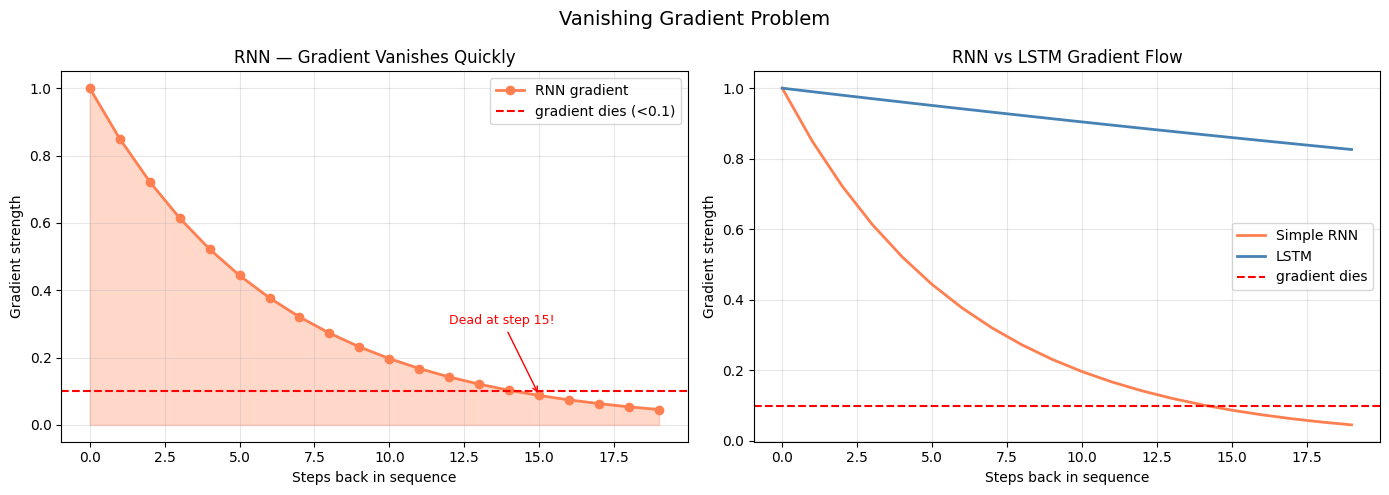

Gradient values at each step:
Step     RNN             LSTM            Status
---------------------------------------------
0        1.000000        1.000000        ✅ alive
1        0.850000        0.990000        ✅ alive
2        0.722500        0.980100        ✅ alive
3        0.614125        0.970299        ✅ alive
4        0.522006        0.960596        ✅ alive
5        0.443705        0.950990        ✅ alive
6        0.377150        0.941480        ✅ alive
7        0.320577        0.932065        ✅ alive
8        0.272491        0.922745        ✅ alive
9        0.231617        0.913517        ✅ alive
10       0.196874        0.904382        ✅ alive
11       0.167343        0.895338        ✅ alive
12       0.142242        0.886385        ✅ alive
13       0.120905        0.877521        ✅ alive
14       0.102770        0.868746        ✅ alive
15       0.087354        0.860058        ❌ dead
16       0.074251        0.851458        ❌ dead
17       0.063113        0.842943        ❌ de

In [7]:
import numpy as np
import matplotlib.pyplot as plt

steps      = 20
gradient   = 1.0
grads_rnn  = []
grads_lstm = []

for step in range(steps):
    gradient_rnn  = 0.85 ** step
    gradient_lstm = 0.99 ** step
    grads_rnn.append(gradient_rnn)
    grads_lstm.append(gradient_lstm)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(grads_rnn, color="coral",
             linewidth=2, marker="o", label="RNN gradient")
axes[0].axhline(y=0.1, color="red", linestyle="--",
                label="gradient dies (<0.1)")
axes[0].fill_between(range(steps), grads_rnn,
                     alpha=0.3, color="coral")
axes[0].set_title("RNN — Gradient Vanishes Quickly")
axes[0].set_xlabel("Steps back in sequence")
axes[0].set_ylabel("Gradient strength")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for i, g in enumerate(grads_rnn):
    if g < 0.1:
        axes[0].annotate(f"Dead at step {i}!",
                         xy=(i, g),
                         xytext=(i-3, 0.3),
                         arrowprops=dict(arrowstyle="->",
                                         color="red"),
                         color="red", fontsize=9)
        break

axes[1].plot(grads_rnn,  color="coral",
             linewidth=2, label="Simple RNN")
axes[1].plot(grads_lstm, color="steelblue",
             linewidth=2, label="LSTM")
axes[1].axhline(y=0.1, color="red",
                linestyle="--", label="gradient dies")
axes[1].set_title("RNN vs LSTM Gradient Flow")
axes[1].set_xlabel("Steps back in sequence")
axes[1].set_ylabel("Gradient strength")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Vanishing Gradient Problem", fontsize=14)
plt.tight_layout()
plt.show()

print("Gradient values at each step:")
print(f"{'Step':<8} {'RNN':<15} {'LSTM':<15} {'Status'}")
print("-" * 45)
for i in range(steps):
    status = "✅ alive" if grads_rnn[i] > 0.1 else "❌ dead"
    print(f"{i:<8} {grads_rnn[i]:<15.6f} "
          f"{grads_lstm[i]:<15.6f} {status}")

WHY gradient vanishes — the math:

RNN forward pass:
  h_t = tanh(W_h × h_(t-1) + W_x × x_t)

Backpropagation through time (BPTT):
  gradient = dL/dh_t × dh_t/dh_(t-1) × ...
           = W_h × (1 - tanh²(h)) × ...

tanh derivative is always < 1:

  Max tanh derivative = 0.9991
  At x=0 derivative   = 1.0000
  At x=2 derivative   = 0.0707

Multiply derivative across 20 steps:


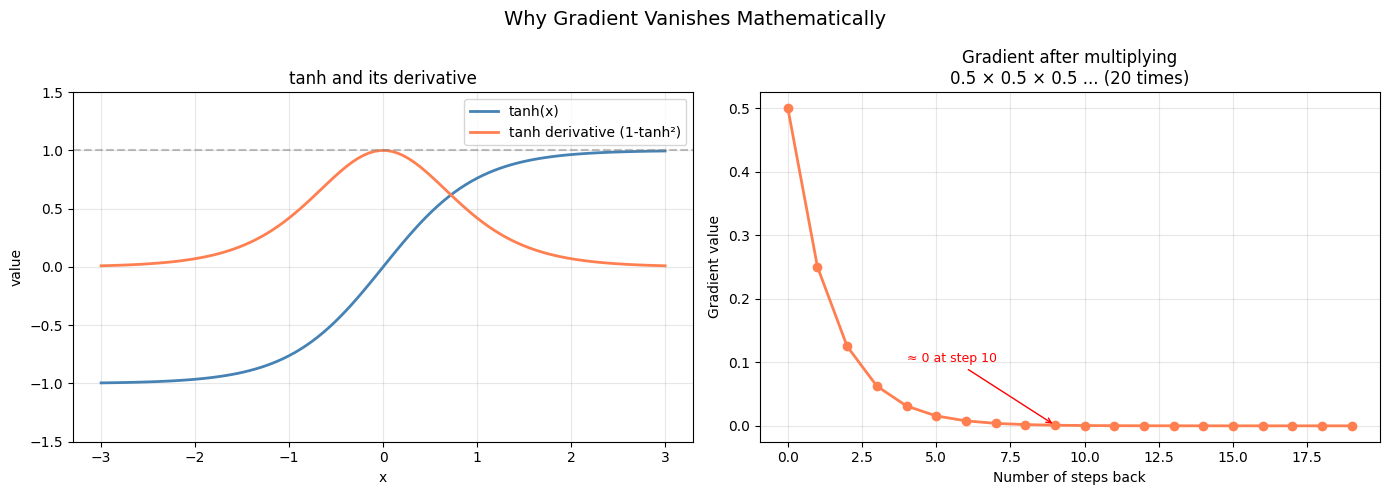

Gradient after multiplying 0.5 across steps:
  Step  1: 0.50000000 ✅
  Step  2: 0.25000000 ✅
  Step  3: 0.12500000 ✅
  Step  4: 0.06250000 ✅
  Step  5: 0.03125000 ✅
  Step  6: 0.01562500 ✅
  Step  7: 0.00781250 ❌ essentially zero
  Step  8: 0.00390625 ❌ essentially zero
  Step  9: 0.00195312 ❌ essentially zero
  Step 10: 0.00097656 ❌ essentially zero


In [8]:
import numpy as np
import matplotlib.pyplot as plt

print("WHY gradient vanishes — the math:")
print("=" * 55)
print()
print("RNN forward pass:")
print("  h_t = tanh(W_h × h_(t-1) + W_x × x_t)")
print()
print("Backpropagation through time (BPTT):")
print("  gradient = dL/dh_t × dh_t/dh_(t-1) × ...")
print("           = W_h × (1 - tanh²(h)) × ...")
print()
print("tanh derivative is always < 1:")

x_vals     = np.linspace(-3, 3, 100)
tanh_vals  = np.tanh(x_vals)
dtanh_vals = 1 - np.tanh(x_vals)**2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(x_vals, tanh_vals,
             color="steelblue", linewidth=2, label="tanh(x)")
axes[0].plot(x_vals, dtanh_vals,
             color="coral", linewidth=2,
             label="tanh derivative (1-tanh²)")
axes[0].axhline(y=1.0, color="gray", linestyle="--", alpha=0.5)
axes[0].set_title("tanh and its derivative")
axes[0].set_xlabel("x")
axes[0].set_ylabel("value")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-1.5, 1.5)

print(f"\n  Max tanh derivative = {dtanh_vals.max():.4f}")
print(f"  At x=0 derivative   = {float(1-np.tanh(0)**2):.4f}")
print(f"  At x=2 derivative   = {float(1-np.tanh(2)**2):.4f}")
print()
print("Multiply derivative across 20 steps:")

steps      = 20
derivative = 0.5
accumulated = [derivative**i for i in range(1, steps+1)]

axes[1].plot(accumulated, color="coral",
             linewidth=2, marker="o")
axes[1].set_title("Gradient after multiplying\n0.5 × 0.5 × 0.5 ... (20 times)")
axes[1].set_xlabel("Number of steps back")
axes[1].set_ylabel("Gradient value")
axes[1].grid(True, alpha=0.3)

for i, v in enumerate(accumulated):
    if v < 0.001:
        axes[1].annotate(f"≈ 0 at step {i+1}",
                         xy=(i, v),
                         xytext=(i-5, 0.1),
                         arrowprops=dict(arrowstyle="->",
                                         color="red"),
                         color="red", fontsize=9)
        break

plt.suptitle("Why Gradient Vanishes Mathematically", fontsize=14)
plt.tight_layout()
plt.show()

print("Gradient after multiplying 0.5 across steps:")
for i, v in enumerate(accumulated[:10]):
    status = "✅" if v > 0.01 else "❌ essentially zero"
    print(f"  Step {i+1:>2}: {v:.8f} {status}")

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

review = [
    "the","weather","was","nice","today",
    "and","we","went","outside","and",
    "played","games","and","had","food",
    "and","the","movie","was","fantastic"
]

n_steps     = len(review)
memory      = []
current_mem = 1.0

for i in range(n_steps):
    current_mem = current_mem * 0.82
    memory.append(current_mem)

fig, ax = plt.subplots(figsize=(16, 6))

colors_list = ["coral" if m < 0.1 else
               "orange" if m < 0.4 else
               "steelblue"
               for m in memory]

bars = ax.bar(range(n_steps), memory,
              color=colors_list, edgecolor="black",
              alpha=0.8)

for i, (word, mem) in enumerate(zip(review, memory)):
    ax.text(i, mem + 0.02, word,
            ha="center", va="bottom",
            fontsize=8, rotation=45)
    ax.text(i, mem/2, f"{mem:.2f}",
            ha="center", va="center",
            fontsize=7, color="white",
            fontweight="bold")

ax.axhline(y=0.1, color="red",
           linestyle="--", linewidth=2,
           label="Memory threshold (0.1)")
ax.set_title("RNN Memory of Each Word by Final Step\n"
             "'fantastic' is at step 20 — but RNN barely remembers 'the' from step 1!",
             fontsize=12)
ax.set_xlabel("Word position in review")
ax.set_ylabel("How much RNN remembers at final step")
ax.legend()

alive  = mpatches.Patch(color="steelblue", label="Remembered well")
fading = mpatches.Patch(color="orange",    label="Fading memory")
dead   = mpatches.Patch(color="coral",     label="Forgotten (< 0.1)")
ax.legend(handles=[alive, fading, dead])

plt.tight_layout()
plt.show()

print("\nMemory of each word at final prediction step:")
print(f"{'Word':<12} {'Memory':<10} {'Status'}")
print("-" * 35)
for word, mem in zip(review, memory):
    if mem > 0.4:
        status = "✅ remembered well"
    elif mem > 0.1:
        status = "⚠️  fading"
    else:
        status = "❌ forgotten"
    print(f"{word:<12} {mem:<10.4f} {status}")